### 0 - Objectifs

Cette partie à pour objectifs d'appliquer notre modèle aux données AROME et de tester les performances en comparant les prédictions réalisées aux données réelles 

### 1 - Imports des librairies 

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, DateType,time
from pyspark.sql.functions import month, dayofweek, hour, udf, lit, col
from pyspark.sql.functions import first

# Création de la session Spark avec le connecteur Cassandra
spark = SparkSession.builder \
    .appName("Prédiction_conso_elec") \
    .config("spark.cassandra.connection.host", "172.17.0.3") \
    .config("spark.cassandra.connection.port", "9042") \
    .getOrCreate()

In [ ]:
Chargement des librairies

### 2- Récupération des données provenant d'AROME depuis Cassandra

Une seule carte étant chargée dans Cassandra sur 24h et seulement sur la région Grand EST. On récupère donc toutes les données 

In [56]:
mesures_des_stations_arome = spark.read.format("org.apache.spark.sql.cassandra").options(table="mesures_stations_arome", keyspace="consom").load()

In [3]:
mesures_des_stations_arome.columns


['id_station', 'timestamp', 'annee', 'heure', 'jour', 'mois', 'saison', 't']

In [57]:
#A partir du lundi 24 février : 
mesures_des_stations_arome=mesures_des_stations_arome.where(mesures_des_stations_arome.timestamp>='2025-02-24T23:00:00')

In [58]:
mesures_des_stations_arome.count()

5635

In [ ]:
#On créée la table dédié : 

In [59]:
from pyspark.sql.types import DoubleType, IntegerType
import pyspark.sql.functions as F
mesures_des_stations_arome = mesures_des_stations_arome.withColumn("t", F.col("t").cast(DoubleType()))
groupe_colonnes = mesures_des_stations_arome.groupBy('timestamp', "saison","mois","jour","heure")
pivot_mesures_des_stations = groupe_colonnes.pivot('id_station').agg(\
    first("t").alias("t"))

#On garde les colonnes en mémoire pour la création du vecteur: 
colonnes_a_garder = pivot_mesures_des_stations.columns
colonnes_pour_vecteur = pivot_mesures_des_stations.columns
#On supprime timestamp + les 2 stations qui ont été écartées lors de l'imputation : 
colonnes_pour_vecteur.remove('timestamp')
colonnes_pour_vecteur.remove('08207001')
colonnes_pour_vecteur.remove('10042001')
#Apres essais, le mois diminue la prédiction
colonnes_pour_vecteur.remove('mois')  

### 3- Transformation des données et application du pipeline : 

In [ ]:
#import des bibliothèques 

In [60]:
from pyspark.ml.feature import StandardScaler, PCA
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import VectorAssembler

In [61]:
 #1- Vecteur assembleur : 
assembleur = VectorAssembler().setInputCols(colonnes_pour_vecteur).setOutputCol("features")
# Construction du Dataframe mesures en appliquant le VectorAssembler sur les données 
mesures_arome = assembleur.transform(pivot_mesures_des_stations).select('timestamp','features').cache()

In [7]:
from pyspark.ml import PipelineModel
MonPipeline = PipelineModel.load("Predicteurs/ModelFinal2025")

In [66]:
MonPipeline.stages

[StandardScalerModel: uid=StandardScaler_e67aa394cb95, numFeatures=117, withMean=true, withStd=true,
 PCAModel: uid=PCA_c88b9aee1b58, k=5,
 RandomForestRegressionModel: uid=RandomForestRegressor_7598b95c9034, numTrees=120, numFeatures=5]

In [62]:
prediction_model = MonPipeline.transform(mesures_arome)

In [63]:
prediction_model.select("timestamp","features", "prediction").orderBy("timestamp").show(20)

+-------------------+--------------------+------------------+
|          timestamp|            features|        prediction|
+-------------------+--------------------+------------------+
|2025-02-24 23:00:00|[4.0,2.0,23.0,7.0...| 20285.07952084108|
|2025-02-25 00:00:00|[4.0,3.0,0.0,7.40...| 19373.17213879584|
|2025-02-25 01:00:00|[4.0,3.0,1.0,6.80...|19280.369751270475|
|2025-02-25 02:00:00|[4.0,3.0,2.0,6.09...| 19456.08630980608|
|2025-02-25 03:00:00|[4.0,3.0,3.0,6.19...| 19444.22375173965|
|2025-02-25 04:00:00|[4.0,3.0,4.0,6.30...|19974.732805718915|
|2025-02-25 05:00:00|[4.0,3.0,5.0,6.90...| 20775.79240319139|
|2025-02-25 06:00:00|[4.0,3.0,6.0,7.19...|21134.763397837123|
|2025-02-25 07:00:00|[4.0,3.0,7.0,7.30...| 21467.18341888564|
|2025-02-25 08:00:00|[4.0,3.0,8.0,7.5,...|21934.929869801217|
|2025-02-25 09:00:00|[4.0,3.0,9.0,7.59...| 21963.46988336855|
|2025-02-25 10:00:00|[4.0,3.0,10.0,8.5...|22112.808918271414|
|2025-02-25 11:00:00|[4.0,3.0,11.0,9.0...|21881.736875522158|
|2025-02

In [64]:
prediction_model= prediction_model.select("timestamp","features", "prediction").orderBy("timestamp").toPandas()

### 4- Comparaison entre la prédiction réalisée par le modèle et les données réelles

#### a- Récupération des données RTE via l'API dédiée 

A noter qu'idéalement ces données sont prévues pour être stockées dans Cassandra. Néanmoins RTE semble consolider les données du mois en cours et il peut y avoir de légères variations. 

Le code ci-dessous permet de récupérer la journée du 9 février: 

import json
import requests
import time
import datetime
import os
import pandas as pd

def recupData(date):
    url = "https://odre.opendatasoft.com/api/explore/v2.1/catalog/datasets/eco2mix-regional-tr/records?select=libelle_region%2C%20date%2C%20date_heure%2C%20consommation&where=date%3D%22"+date+"%22&order_by=date_heure&limit=-1&refine=libelle_region%3A%22Grand%20Est%22"
    #url = "https://odre.opendatasoft.com/api/explore/v2.1/catalog/datasets/eco2mix-regional-tr/records?select=libelle_region%2C%20date%2C%20date_heure%2C%20consommation&where=date%3D%22"+date+"%22&order_by=date_heure&refine=libelle_region%3A%22Grand%20Est%22"
    response = requests.get(url)
    return response.content

content1 = json.loads(recupData('2025-02-09'))
content2 = json.loads(recupData('2025-02-10'))
content3 = json.loads(recupData('2025-02-11'))
content4 = json.loads(recupData('2025-02-12'))
content5 = json.loads(recupData('2025-02-13'))
content6 = json.loads(recupData('2025-02-14'))
content7 = json.loads(recupData('2025-02-15'))
content1 = pd.DataFrame(content1['results'])
content2 = pd.DataFrame(content2['results'])
content3 = pd.DataFrame(content3['results'])
content4 = pd.DataFrame(content4['results'])
content5 = pd.DataFrame(content5['results'])
content6 = pd.DataFrame(content6['results'])
content7 = pd.DataFrame(content7['results'])
valeurs_RTE = pd.concat([content1,content2,content3,content4,content5,content6],ignore_index=True)
print(valeurs_RTE.count())
valeurs_RTE['date'] = pd.to_datetime(valeurs_RTE['date'])
valeurs_RTE['date_heure'] = pd.to_datetime(valeurs_RTE['date_heure'])
valeurs_RTE = valeurs_RTE.resample('H', on='date_heure').consommation.sum().reset_index()



In [69]:
import json
import requests
import time
import datetime
import os
import pandas as pd

def recupData(date):
    url = "https://odre.opendatasoft.com/api/explore/v2.1/catalog/datasets/eco2mix-regional-tr/records?select=libelle_region%2C%20date%2C%20date_heure%2C%20consommation&where=date%3D%22"+date+"%22&order_by=date_heure&limit=-1&refine=libelle_region%3A%22Grand%20Est%22"
    #url = "https://odre.opendatasoft.com/api/explore/v2.1/catalog/datasets/eco2mix-regional-tr/records?select=libelle_region%2C%20date%2C%20date_heure%2C%20consommation&where=date%3D%22"+date+"%22&order_by=date_heure&refine=libelle_region%3A%22Grand%20Est%22"
    response = requests.get(url)
    return response.content

content2 = json.loads(recupData('2025-02-25'))
content2 = pd.DataFrame(content2['results'])
valeurs_RTE = pd.concat([content2],ignore_index=True)
print(valeurs_RTE.count())
valeurs_RTE['date'] = pd.to_datetime(valeurs_RTE['date'])
valeurs_RTE['date_heure'] = pd.to_datetime(valeurs_RTE['date_heure'])
valeurs_RTE = valeurs_RTE.resample('H', on='date_heure').consommation.sum().reset_index()

libelle_region    96
date              96
date_heure        96
consommation      96
dtype: int64


In [70]:
valeurs_RTE.sort_values(by='date_heure')

,date_heure,consommation
0,2025-02-24 23:00:00+00:00,18922
1,2025-02-25 00:00:00+00:00,18373
2,2025-02-25 01:00:00+00:00,18280
3,2025-02-25 02:00:00+00:00,17684
4,2025-02-25 03:00:00+00:00,17483
5,2025-02-25 04:00:00+00:00,18060
6,2025-02-25 05:00:00+00:00,19973
7,2025-02-25 06:00:00+00:00,21127
8,2025-02-25 07:00:00+00:00,21751
9,2025-02-25 08:00:00+00:00,22594


#### b- Comparaison entre la prédiction et les données réelles

Les données de RTE et donc les résultats peuvent fluctuer ici

In [53]:
    prediction_model.to_csv(path_or_buf='test.csv',sep=';')

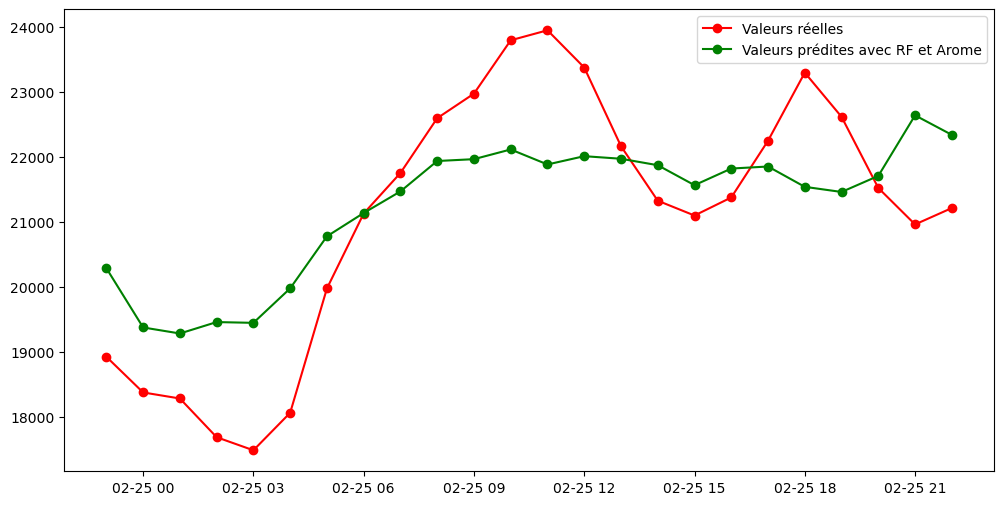

In [71]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
# Tracer les valeurs réelles
#y_test_2 = y_test.reset_index(drop=True)
#plt.plot(y_predict_ridge, label="Valeurs prédites ridge", color='red', marker='o')
plt.plot(valeurs_RTE['date_heure'][:], valeurs_RTE['consommation'][:], label="Valeurs réelles", color='red', marker='o')
plt.plot(prediction_model['timestamp'][0:24], prediction_model['prediction'][0:24], label="Valeurs prédites avec RF et Arome", color='green', marker='o')
#plt.plot(dfpandas['label'].iloc[500:700], label="Valeurs réelles", color='blue', marker='o')
plt.legend()

In [21]:
#On calcul rapidement les performances avec MAPE

In [72]:
test_performance= pd.DataFrame()
test_performance["consommation_reel"] = valeurs_RTE['consommation']
test_performance["prediction"] = prediction_model['prediction']

In [73]:
#On calcul le MAPE  :
#On calcul les écarts entre la valeur réelle et la valeur prédite 
test_performance['ecartM'] = abs((test_performance["consommation_reel"]- test_performance["prediction"])/test_performance["consommation_reel"])
MAPE= 100*(test_performance['ecartM'].mean())
print("Mean Absolute Percentage Error :"+str(round(MAPE,2))+"%")

Mean Absolute Percentage Error :5.02%


Il est trop tôt pour tirer des conclusions hâtives mais les résultats sont ici plutôt prometteurs. 

In [24]:
spark.stop()